
# Exploratory Data Analysis (EDA)

**Exploratory Data Analysis** (EDA) is the detective work of data science. Before any modeling begins, we must understand the nature of the evidence we have collected. It involves summarizing the main characteristics of a dataset, often using visual and statistical methods.

The primary goal is not just to make pretty charts, but to "get a feel" for the data - understanding its structure, its quirks, and its potential pitfalls.

## Goals of EDA

EDA helps us answer critical questions:

-   **Structure**: What are the data types? How many observations do we have?
-   **Quality**: Are there missing values? Are there duplicate rows?
-   **Outliers**: Are there values that don't make sense (e.g., a house with 0 rooms or negative price)?
-   **Patterns**: How is the data distributed? Is it skewed?
-   **Relationships**: Do certain features correlate with the target variable?

## Typical Techniques

We typically alternate between statistical summaries and visualizations:

| Technique                | Purpose                                                                       |
|------------------------ |----------------------------------------------------------------------------- |
| **Summary Statistics**   | Quantitative overview (Mean, Median, Standard Deviation, Quantiles).          |
| **Histograms**           | Understanding the distribution of a single variable (is it Normal/Gaussian?). |
| **Box Plots**            | Identifying outliers and visualizing the spread of data.                      |
| **Scatter Plots**        | Visualizing the relationship between two continuous variables.                |
| **Correlation Heatmaps** | Quickly identifying which variables move together.                            |

## Practical Demonstration: California Housing

We will dissect the California Housing dataset to see what insights we can glean before modeling.

### Load and Inspect

First, we load the data and look at the basic info.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Load the dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Descriptive Statistics

We use `.describe()` to look at the central tendency and spread. **Tip**: Look at the min and max values to check for sanity. For example, if 'AveRooms' had a max of 10,000, that would be suspicious.

In [2]:
print(df.describe().T) # Transpose (.T) makes it easier to read with many columns

               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
AveRooms     20640.0     5.429000     2.474173    0.846154    4.440716   
AveBedrms    20640.0     1.096675     0.473911    0.333333    1.006079   
Population   20640.0  1425.476744  1132.462122    3.000000  787.000000   
AveOccup     20640.0     3.070655    10.386050    0.692308    2.429741   
Latitude     20640.0    35.631861     2.135952   32.540000   33.930000   
Longitude    20640.0  -119.569704     2.003532 -124.350000 -121.800000   
MedHouseVal  20640.0     2.068558     1.153956    0.149990    1.196000   

                     50%          75%           max  
MedInc          3.534800     4.743250     15.000100  
HouseAge       29.000000    37.000000     52.000000  
AveRooms        5.229129     6.052381    141.909091  
AveBedrms       1.048780     1.099526     3

### Checking for Missing Values

Real-world data is rarely clean. We must check for nulls.

In [3]:
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0]) # Only print columns with missing data

Missing values per column:
Series([], dtype: int64)


**Note**: This dataset is pre-cleaned, so we expect 0 missing values.

### Univariate Analysis (Distributions)

Let's analyze the Target Variable (`MedHouseVal`) and a key feature (`MedInc`). We use histograms to see the shape of the data.

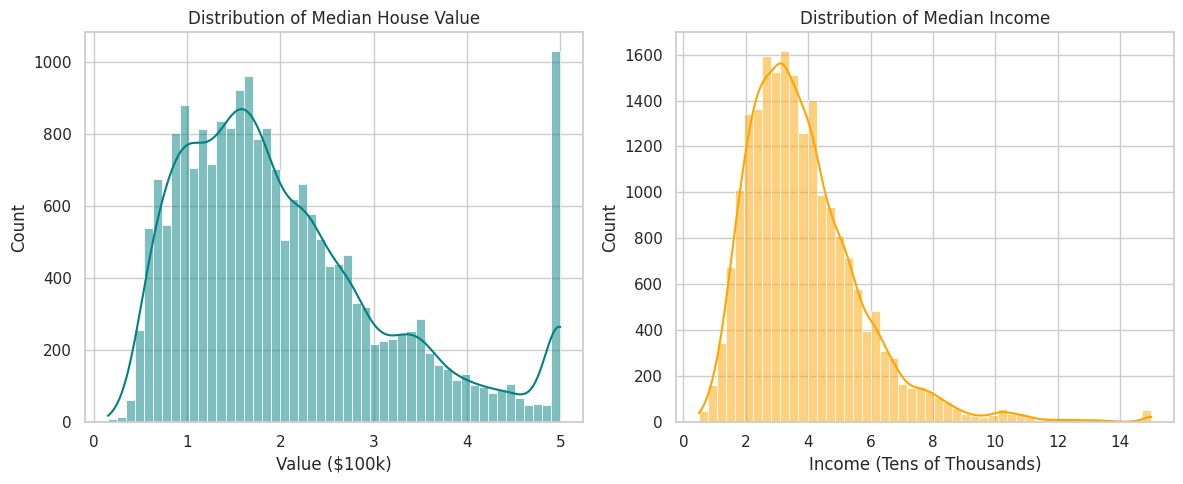

In [4]:
plt.figure(figsize=(12, 5))

# Plot 1: House Value
plt.subplot(1, 2, 1)
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='teal')
plt.title('Distribution of Median House Value')
plt.xlabel('Value ($100k)')

# Plot 2: Income
plt.subplot(1, 2, 2)
sns.histplot(df['MedInc'], bins=50, kde=True, color='orange')
plt.title('Distribution of Median Income')
plt.xlabel('Income (Tens of Thousands)')

plt.tight_layout()
plt.show()

**Observation**: Notice the spike at the far right of the House Value graph? That indicates "censored" data - values higher than 5.0 were likely capped at 5.0 during data collection. This is a critical finding for modeling!

### Bivariate Analysis (Relationships)

We use a Correlation Matrix to identify linear relationships.

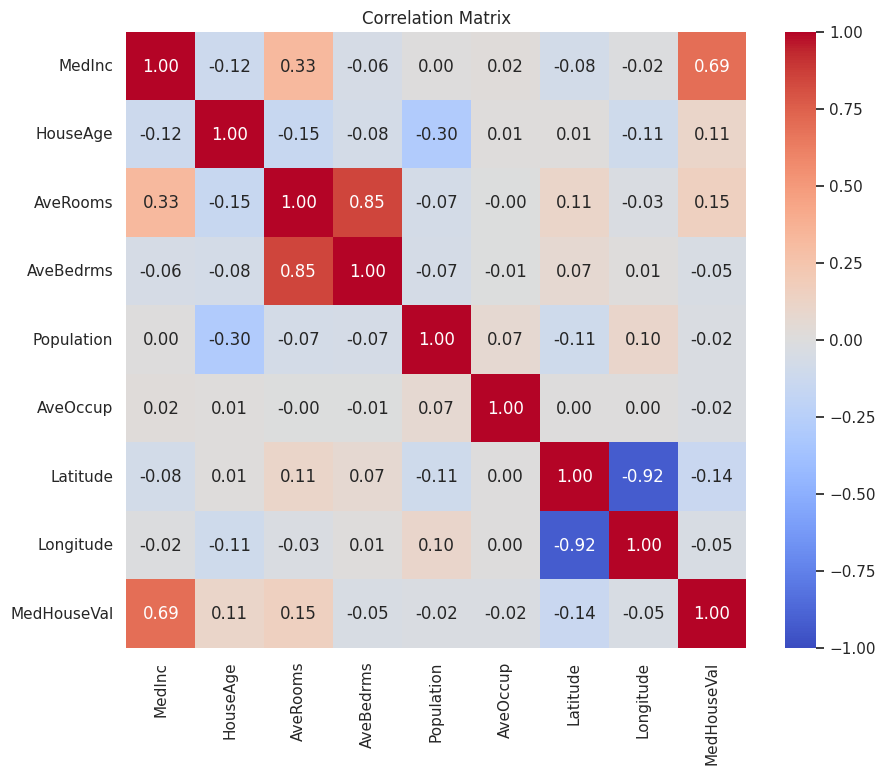

In [5]:
plt.figure(figsize=(10, 8))

# Plot heatmap
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

We can also visualize specific relationships using scatter plots. Since the dataset is large (20k+ rows), we sample it to make the plot clearer.

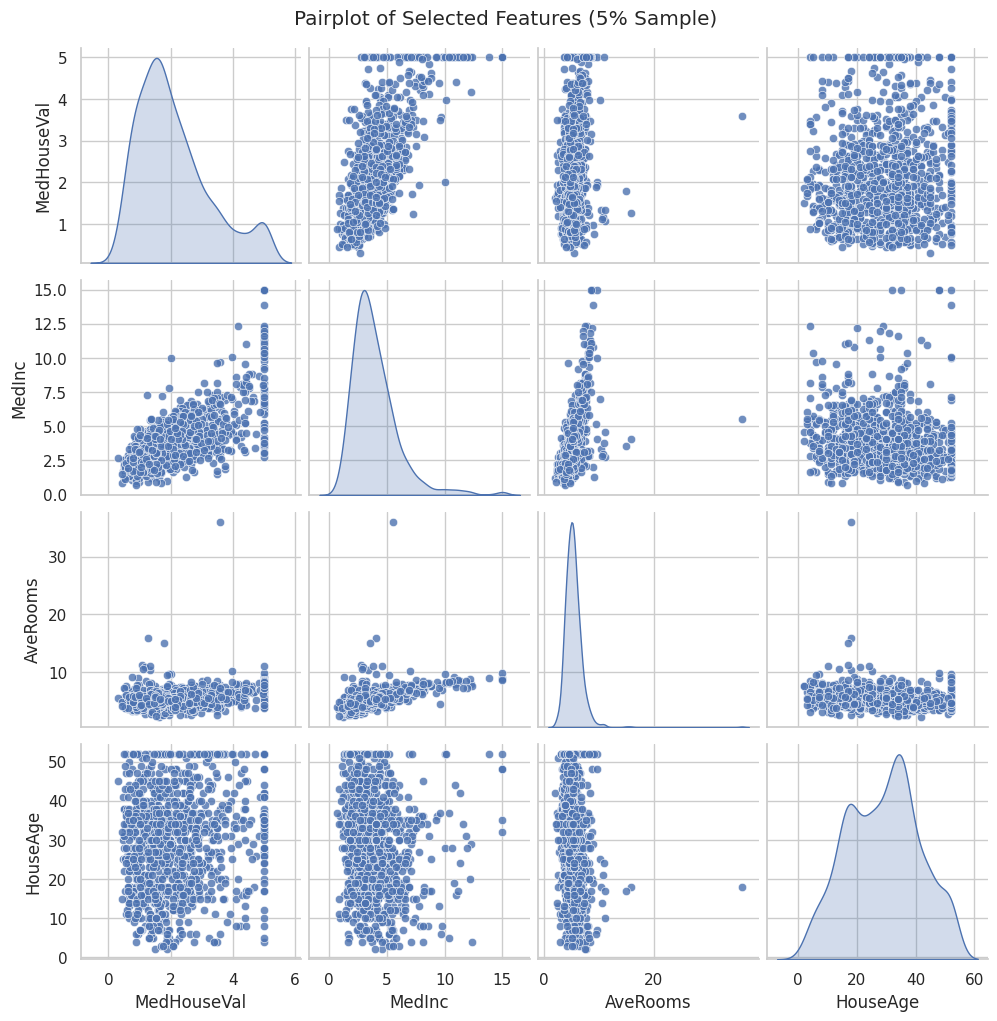

In [6]:
# Sample 5% of the data for cleaner plotting
df_sample = df.sample(frac=0.05, random_state=42)

sns.pairplot(df_sample, 
             vars=['MedHouseVal', 'MedInc', 'AveRooms', 'HouseAge'], 
             diag_kind='kde', 
             plot_kws={'alpha': 0.8})
plt.suptitle('Pairplot of Selected Features (5% Sample)', y=1.02)
plt.show()

## Exercises

Now, apply these techniques to the ****Ames Housing dataset****. This dataset is much "dirtier" and wider than California Housing, making EDA even more important.

### Load and Inspect

-   Load the dataset.
-   Print the shape.
-   Identify how many columns are numerical vs. categorical (object).

In [7]:
from sklearn.datasets import fetch_openml

# Load data
ames_data = fetch_openml(name='house_prices', as_frame=True, parser="auto")
df_ames = ames_data.frame

print(f"Shape: {df_ames.shape}")

# Count data types
print(df_ames.dtypes.value_counts())

Shape: (1460, 81)
str        43
int64      35
float64     3
Name: count, dtype: int64


### Missing Value Hunt

Unlike California, Ames has missing data.

-   Calculate the percentage of missing values for each column.
-   Display the top 10 columns with the most missing data.

In [8]:
# Calculate percentage
missing_pct = df_ames.isnull().mean() * 100

# Filter only those with missing values and sort
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("Top 10 columns with missing values (%):")
print(missing_pct.head(10))

Top 10 columns with missing values (%):
PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
FireplaceQu     47.260274
LotFrontage     17.739726
GarageCond       5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
dtype: float64


### Visualizing Categories (Boxplots)

We want to see how categorical features affect the price.

-   Create a boxplot for `OverallQual` (Overall Quality) vs. `SalePrice`.
-   This shows how the median price changes with quality rating.

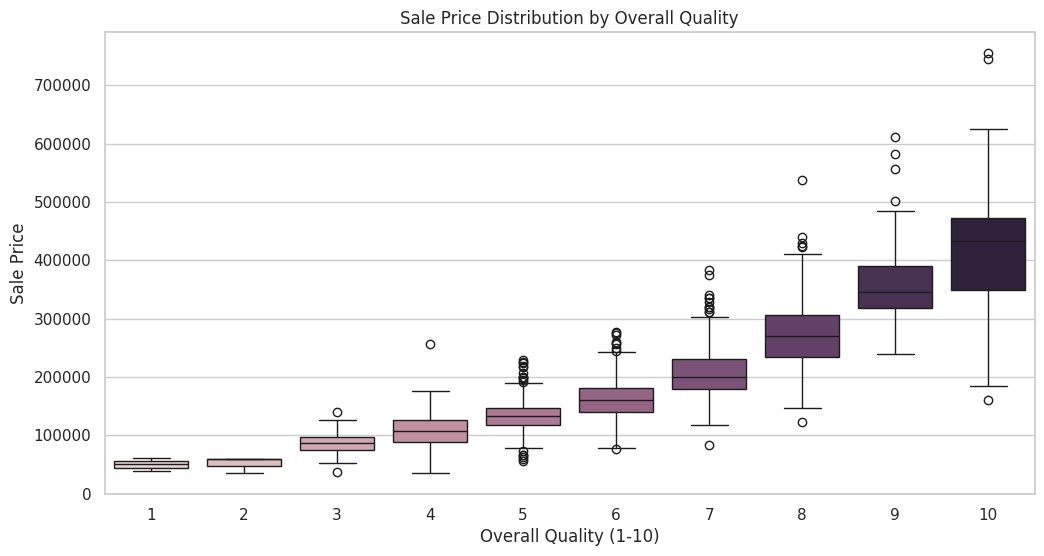

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df_ames, hue="OverallQual", legend=False)
plt.title('Sale Price Distribution by Overall Quality')
plt.xlabel('Overall Quality (1-10)')
plt.ylabel('Sale Price')
plt.show()

### Target Distribution

-   Plot the distribution of `SalePrice`.
-   Is it skewed? (Real estate prices usually are).

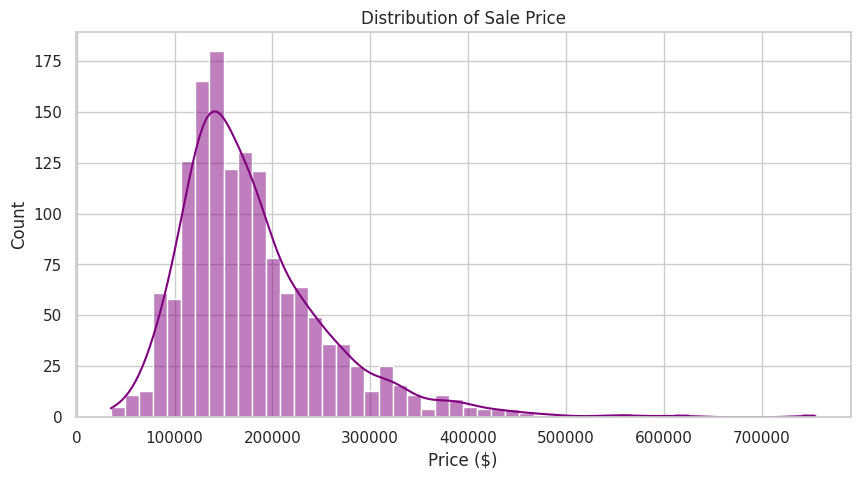

Skewness: 1.88


In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df_ames['SalePrice'], bins=50, kde=True, color='purple')
plt.title('Distribution of Sale Price')
plt.xlabel('Price ($)')
plt.show()

print(f"Skewness: {df_ames['SalePrice'].skew():.2f}")

## Summary

In this module, we practiced the art of **Exploratory Data Analysis**.

1.  We inspected data structure and types using `.info()` and `.describe()`.
2.  We visualized distributions using **Histograms** and discovered data capping in the California dataset.
3.  We analyzed relationships using **Heatmaps** and **Scatter Plots**.
4.  In the exercises, we tackled real-world issues like missing values and categorical data visualization in the Ames dataset.

Remember: **Garbage In, Garbage Out**. EDA is your primary defense against bad models.